# Drift-Diffusion Models (`pyem.models.ddm`)

## Two value-based choice tasks, each in a 4- and a 7-parameter form


This module provides **four** drift-diffusion models: two *tasks*, each in a
four-parameter and a seven-parameter ("full DDM") form. All four share one Wiener
first-passage-time (WFPT) likelihood (Navarro & Fuss, 2009) and one vectorized
Euler-Maruyama simulator; each model differs only in its **task** (how the trial
drift is constructed) and its **parameter set**.

Evidence accumulates as a Wiener diffusion between two absorbing boundaries, starting
at $z\,a$ (relative bias $z \in (0,1)$) with unit noise:

- **upper** boundary (at $a$) $\rightarrow$ `choice = 1`
- **lower** boundary (at $0$) $\rightarrow$ `choice = 0`

### Task 1 — high-vs-low value (`ddm4`, `ddm7`)

Each trial offers two *certain* amounts, $\text{value}_{\text{high}} >
\text{value}_{\text{low}}$; the agent should choose the higher one. The drift is the
value gap and points at the UPPER (correct/HIGH) boundary, so the task has a
well-defined accuracy and difficulty = the gap:

$$
v = v_{\text{coef}} \cdot (\text{value}_{\text{high}} - \text{value}_{\text{low}}) \ge 0,
\qquad \text{upper} = \text{HIGH (correct)},\; \text{lower} = \text{LOW (error)}. \tag{1}
$$

### Task 2 — safe-vs-risky gamble (`ddm4_lotto`, `ddm7_lotto`)

Each trial pits a RISKY gamble (win probability $p$, payoff, so
$\text{EV}_{\text{risky}} = p\cdot\text{payoff}$) against a SAFE certain amount. The
drift is the risky-minus-safe value difference and can point either way:

$$
v = v_{\text{coef}} \cdot (\text{EV}_{\text{risky}} - \text{safe}),
\qquad \text{upper} = \text{RISKY},\; \text{lower} = \text{SAFE}. \tag{2}
$$

### Four parameters vs seven

The **four-parameter** models (`ddm4`, `ddm4_lotto`) have `[v_coef, a, t0, z]` — drift
scaling, boundary separation $a$, non-decision time $t_0$, start-point bias $z$. The
**seven-parameter** models (`ddm7`, `ddm7_lotto`) add the three across-trial
variability parameters of the full diffusion model (Ratcliff & Tuerlinckx, 2002):
$s_v$ (SD of a Normal on the trial drift), $s_t$ (full width of a Uniform on $t_0$),
$s_z$ (full width of a Uniform on the relative $z$). Setting $s_v = s_t = s_z = 0$
reduces each 7-parameter model **exactly** to its 4-parameter sibling.

### Likelihood

The lower-boundary WFPT density factorizes (Navarro & Fuss, 2009) into a drift/scale
term times the first-passage density of the *driftless* unit-separation process in
normalized time $\tau = t/a^2$:

$$
p(t \mid v, a, z) = \frac{1}{a^2}\, e^{-vaz - v^2 t/2}\; f(\tau \mid z). \tag{3}
$$

The drift variability $s_v$ is marginalized analytically (Ratcliff & Tuerlinckx,
2002); $s_t$ and $s_z$ by Gauss-Legendre quadrature. The UPPER-boundary density uses
the reflection $v \to -v$, $z \to 1-z$. The variability parameters are **weakly
identified** for recovery in these value-based designs (see the module docstring's
Recoverability note), so the 4-parameter models are recommended for recovery; the
7-parameter models are used below to *visualize* what $s_v$ does to the data.


In [7]:
import os
os.environ.setdefault("PYTHONWARNINGS", "ignore")
import warnings
from scipy.optimize import OptimizeWarning
# Nelder-Mead ignores the harness's default BFGS options (gtol/eps); silence that noise
warnings.filterwarnings("ignore", category=OptimizeWarning)

import numpy as np
from pyem import EMModel
from pyem.models.ddm import (
    ddm4_model, ddm4_lotto_model,
    ddm4_sim, ddm4_lotto_sim, 
    wfpt_logpdf, _marginal_logpdf,
)
import sys; sys.path.insert(0, ".")  # so `from params import build_params` works when run from examples/
from params import build_params

# each ModelSpec bundles a model's identity, task, and sim/fit entry points
for m in (ddm4_model, ddm7_model, ddm4_lotto_model, ddm7_lotto_model):
    print(f"{m.id:12s} | task={m.spec['task']:22s} | boundaries={m.spec['boundaries']}")


ddm4         | task=high_vs_low_value      | boundaries={'upper': 'high (correct)', 'lower': 'low (error)'}
ddm7         | task=high_vs_low_value      | boundaries={'upper': 'high (correct)', 'lower': 'low (error)'}
ddm4_lotto   | task=safe_vs_risky_gamble   | boundaries={'upper': 'risky', 'lower': 'safe'}
ddm7_lotto   | task=safe_vs_risky_gamble   | boundaries={'upper': 'risky', 'lower': 'safe'}


### Sanity check: the WFPT log-density matches a fine-grid numerical reference

Before fitting, we confirm `wfpt_logpdf` (the shared likelihood, which adaptively
selects the small-/large-time series) agrees with an independent large-time-series
reference summed to many terms.


In [8]:
def numerical_logdens(rt, v, a, z, nterms=5000):
    """Independent large-time-series reference for the lower-boundary density."""
    k = np.arange(1, nterms + 1)
    s = np.sum(k * np.exp(-(k**2) * np.pi**2 * rt / (2 * a**2)) * np.sin(k * np.pi * z))
    return np.log(np.pi / (a**2) * np.exp(-v * a * z - v**2 * rt / 2.0) * s)

for (rt, v, a, z) in [(0.5, 1.0, 1.2, 0.5), (0.15, 2.0, 0.8, 0.3), (2.5, 0.2, 1.5, 0.45)]:
    got, ref = wfpt_logpdf(rt, v, a, z), numerical_logdens(rt, v, a, z)
    print(f"rt={rt:<4} v={v:<5} a={a:<4} z={z:<5} | wfpt={got:+.6f}  ref={ref:+.6f}  |diff|={abs(got-ref):.2e}")


rt=0.5  v=1.0   a=1.2  z=0.5   | wfpt=-1.783390  ref=-1.783390  |diff|=2.22e-16
rt=0.15 v=2.0   a=0.8  z=0.3   | wfpt=-0.486788  ref=-0.486788  |diff|=5.55e-17
rt=2.5  v=0.2   a=1.5  z=0.45  | wfpt=-5.346702  ref=-5.346702  |diff|=1.78e-15


### Parameter recovery for the two four-parameter models

We recover the two recommended (four-parameter) models — `ddm4` on the high-vs-low
value task and `ddm4_lotto` on the safe-vs-risky gamble task — with hierarchical
EM + MAP (`EMModel.recover`). Each simulates a cohort, fits every subject, and reports
the Pearson correlation between true and recovered parameters. The WFPT likelihood is
mildly non-smooth (series selection + underflow floor), so we fit with the
derivative-free Nelder-Mead optimizer. The two models take different task variables
(`value_high`/`value_low` vs `ev_risky`/`safe`), passed via `pr_inputs`.


C:\Users\Shawn\AppData\Local\Temp\ipykernel_35968\1753059801.py:9: UserWarning: EMModel.recover() overwrites this model's `all_data` with the data simulated from `true_params` and assigns `outfit` from the recovery fit, so get_outfit()/.outfit reflect the recovered model. The recovered estimates are also available via the returned dict's 'recovery_model'.
  recovery_hl = model_hl.recover(


ddm4 (high-vs-low value) recovery: {'v_coef': 0.968, 'a': 0.933, 't0': 0.982, 'z': 0.927}
All four ddm4 parameters recovered with r > 0.5.


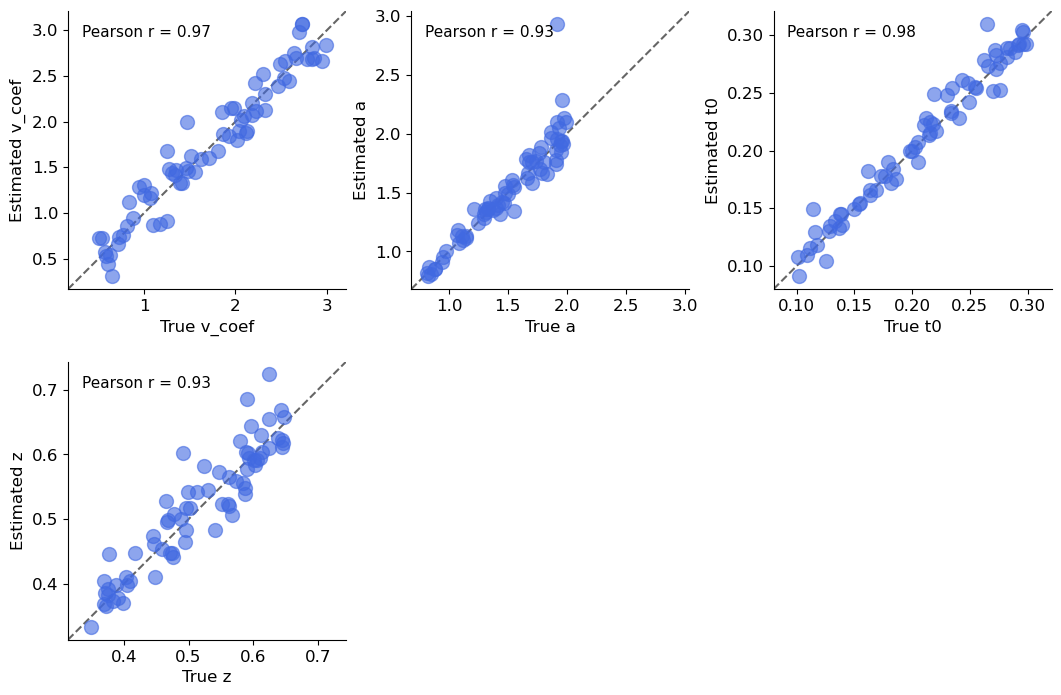

In [9]:
# --- ddm4: high-vs-low value task ---
nsubjects, ntrials = 70, 150
param_names, param_xform, true_params = build_params(
    ["v_coef", "a", "t0", "z"], nsubjects, rng=np.random.default_rng(0))

model_hl = EMModel(all_data=None, fit_func=ddm4_model.fit,
                   param_names=param_names, param_xform=param_xform,
                   simulate_func=ddm4_model.sim)
recovery_hl = model_hl.recover(
    true_params, pr_inputs=["rt", "choice", "value_high", "value_low"],
    ntrials=ntrials, rng=np.random.default_rng(2026),
    fit_kwargs={"seed": 0, "mstep_maxit": 40, "njobs": -1,
                "optim_method": "Nelder-Mead", "max_restarts": 4,
                "optim_options": {"maxiter": 3000, "xatol": 1e-5, "fatol": 1e-5}})
fig = model_hl.plot_recovery(recovery_hl, show=False)
corr_hl = dict(zip(param_names, recovery_hl["correlation"]))
print("ddm4 (high-vs-low value) recovery:",
      {n: round(float(r), 3) for n, r in corr_hl.items()})
assert all(r > 0.5 for r in recovery_hl["correlation"]), corr_hl
print("All four ddm4 parameters recovered with r > 0.5.")

C:\Users\Shawn\AppData\Local\Temp\ipykernel_35968\381746559.py:5: UserWarning: EMModel.recover() overwrites this model's `all_data` with the data simulated from `true_params` and assigns `outfit` from the recovery fit, so get_outfit()/.outfit reflect the recovered model. The recovered estimates are also available via the returned dict's 'recovery_model'.
  recovery_lo = model_lo.recover(


ddm4_lotto (safe-vs-risky gamble) recovery: {'v_coef': 0.972, 'a': 0.979, 't0': 0.979, 'z': 0.976}
All four ddm4_lotto parameters recovered with r > 0.5.


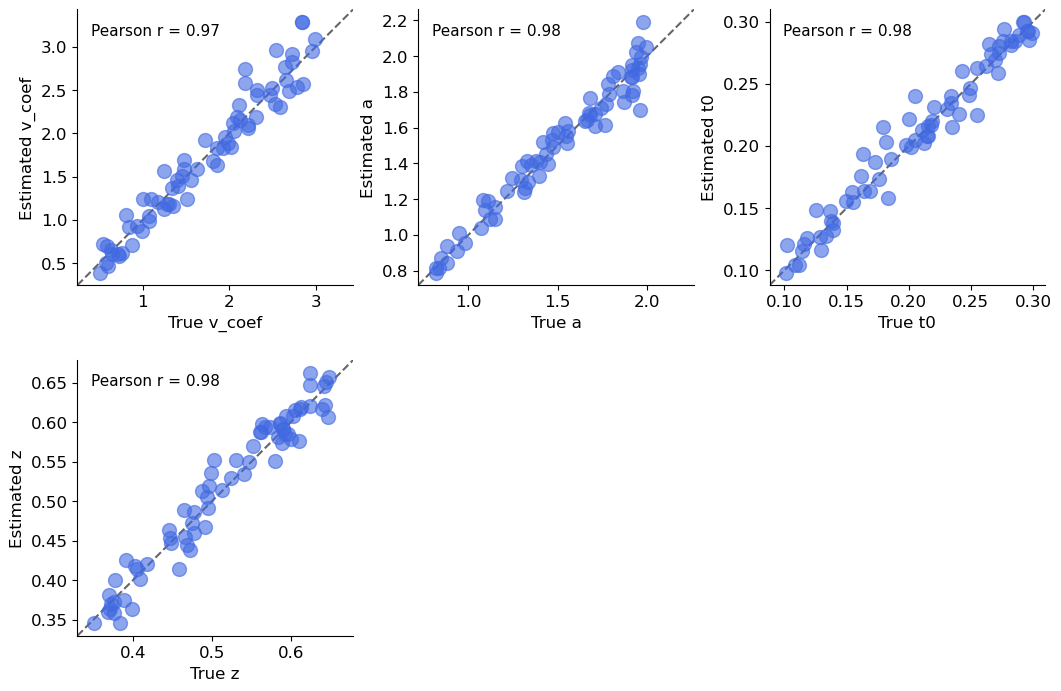

In [10]:
# --- ddm4_lotto: safe-vs-risky gamble task ---
model_lo = EMModel(all_data=None, fit_func=ddm4_lotto_model.fit,
                   param_names=param_names, param_xform=param_xform,
                   simulate_func=ddm4_lotto_model.sim)
recovery_lo = model_lo.recover(
    true_params, pr_inputs=["rt", "choice", "ev_risky", "safe"],
    ntrials=ntrials, rng=np.random.default_rng(2026),
    fit_kwargs={"seed": 0, "mstep_maxit": 40, "njobs": -1,
                "optim_method": "Nelder-Mead", "max_restarts": 4,
                "optim_options": {"maxiter": 3000, "xatol": 1e-5, "fatol": 1e-5}})
fig = model_lo.plot_recovery(recovery_lo, show=False)
corr_lo = dict(zip(param_names, recovery_lo["correlation"]))
print("ddm4_lotto (safe-vs-risky gamble) recovery:",
      {n: round(float(r), 3) for n, r in corr_lo.items()})
assert all(r > 0.5 for r in recovery_lo["correlation"]), corr_lo
print("All four ddm4_lotto parameters recovered with r > 0.5.")


### What does drift variability ($s_v$) do to the data? (high-vs-low task)

The remaining sections use the seven-parameter high-vs-low model (`ddm7`) to visualize
across-trial variability. Because the correct option is always HIGH (the upper
boundary), an **error** here is simply a lower-boundary (LOW) choice — no
value-congruence bookkeeping needed. We simulate one agent with identical core
parameters at $s_v = 0$, $1.5$, and $4$ (holding $s_t = s_z = 0$) and compare the RT
distributions for correct (HIGH/upper), error (LOW/lower), and all trials.

Two comparisons must be kept separate:

1. **Within one $s_v$ level**, errors are *slower* than correct responses — the classic
   "slow errors" signature of drift variability (Ratcliff & McKoon, 2008).
2. **Across $s_v$ levels**, everything speeds up as $s_v$ grows (the typical trial's
   $|{\rm drift}|$ grows with $s_v$), so error RTs at $s_v=4$ are faster than at
   $s_v=0$ even though errors stay slower than correct responses at every level.

The *size* of the within-level slow-error gap rises and then falls with $s_v$,
peaking when $s_v$ is on the order of the mean drift — quantified two cells below.


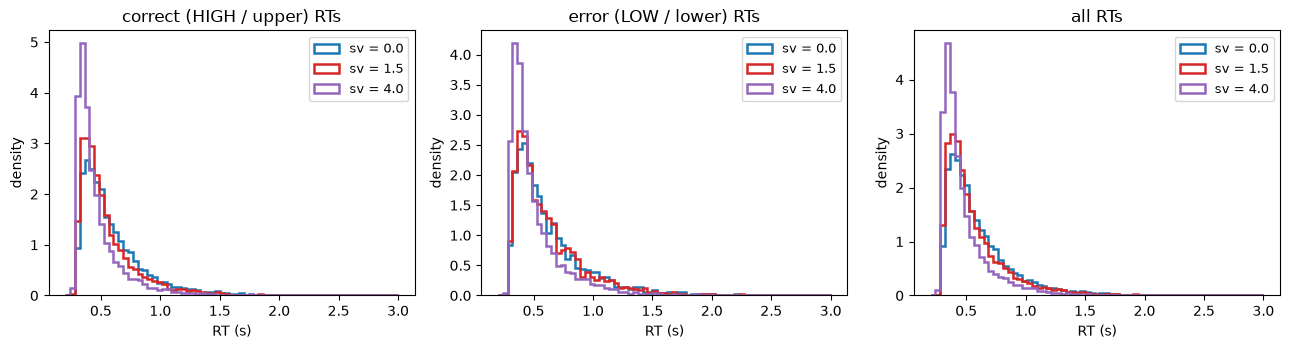

sv=0.0: P(error)=0.197, median RT correct=0.514s, error=0.536s, gap=+0.021s
sv=1.5: P(error)=0.281, median RT correct=0.470s, error=0.530s, gap=+0.061s
sv=4.0: P(error)=0.385, median RT correct=0.397s, error=0.426s, gap=+0.029s


In [5]:
import matplotlib.pyplot as plt

base_p = dict(v_coef=1.5, a=1.3, t0=0.25, z=0.5)
n_show = 12000
sv_levels = (0.0, 1.5, 4.0)
sv_colors = ("tab:blue", "tab:red", "tab:purple")
sims = {}
for sv_val in sv_levels:
    pars = np.array([[base_p["v_coef"], base_p["a"], base_p["t0"], base_p["z"],
                      sv_val, 0.0, 0.0]])
    sims[sv_val] = ddm7_sim(pars, ntrials=n_show, rng=np.random.default_rng(42))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
bins = np.linspace(0.2, 3.0, 70)
for sv_val, color in zip(sv_levels, sv_colors):
    d = sims[sv_val]
    rt, choice = d["rt"][0], d["choice"][0]
    correct = choice == 1          # HIGH = upper = correct
    axes[0].hist(rt[correct], bins=bins, density=True, histtype="step", lw=1.8,
                 color=color, label=f"sv = {sv_val}")
    axes[1].hist(rt[~correct], bins=bins, density=True, histtype="step", lw=1.8,
                 color=color, label=f"sv = {sv_val}")
    axes[2].hist(rt, bins=bins, density=True, histtype="step", lw=1.8,
                 color=color, label=f"sv = {sv_val}")
axes[0].set_title("correct (HIGH / upper) RTs")
axes[1].set_title("error (LOW / lower) RTs")
axes[2].set_title("all RTs")
for ax in axes:
    ax.set_xlabel("RT (s)"); ax.set_ylabel("density"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

for sv_val, d in sims.items():
    rt, choice = d["rt"][0], d["choice"][0]
    err = choice == 0
    print(f"sv={sv_val}: P(error)={err.mean():.3f}, "
          f"median RT correct={np.median(rt[~err]):.3f}s, "
          f"error={np.median(rt[err]):.3f}s, "
          f"gap={np.median(rt[err]) - np.median(rt[~err]):+.3f}s")


#### The slow-error effect is non-monotonic in $s_v$

Sweeping $s_v$: within each level errors stay slower than correct responses, but
everything speeds up as $s_v$ grows, and the error$-$correct **gap** rises then falls
(peaking near $s_v \approx$ the mean drift). The mixture argument (Ratcliff & McKoon,
2008) requires $s_v$ comparable to the mean drift; once $s_v \gg v$ many errors come
from large wrong-way drifts, which are fast.


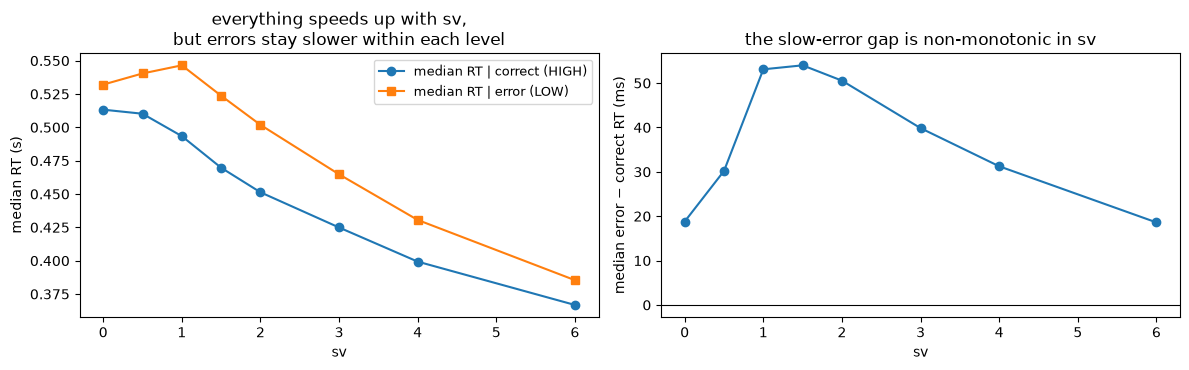

sv= 0.0: P(error)=0.194  correct=0.513s  error=0.532s  gap= +18.8 ms
sv= 0.5: P(error)=0.211  correct=0.510s  error=0.540s  gap= +30.2 ms
sv= 1.0: P(error)=0.247  correct=0.493s  error=0.546s  gap= +53.1 ms
sv= 1.5: P(error)=0.287  correct=0.470s  error=0.524s  gap= +54.0 ms
sv= 2.0: P(error)=0.317  correct=0.451s  error=0.502s  gap= +50.5 ms
sv= 3.0: P(error)=0.361  correct=0.425s  error=0.465s  gap= +39.8 ms
sv= 4.0: P(error)=0.392  correct=0.399s  error=0.431s  gap= +31.2 ms
sv= 6.0: P(error)=0.428  correct=0.367s  error=0.385s  gap= +18.6 ms

Non-monotonicity confirmed: the within-level slow-error gap peaks when sv ~ |v|.


In [6]:
sv_grid = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0]
med_c, med_e, p_err = [], [], []
for sv_val in sv_grid:
    dsw = ddm7_sim(np.array([[1.5, 1.3, 0.25, 0.5, sv_val, 0.0, 0.0]]),
                   ntrials=16000, rng=np.random.default_rng(42))
    rt, choice = dsw["rt"][0], dsw["choice"][0]
    err = choice == 0
    med_c.append(np.median(rt[~err])); med_e.append(np.median(rt[err]))
    p_err.append(err.mean())
med_c, med_e = np.array(med_c), np.array(med_e)
gap = med_e - med_c

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(sv_grid, med_c, "o-", label="median RT | correct (HIGH)")
axes[0].plot(sv_grid, med_e, "s-", label="median RT | error (LOW)")
axes[0].set_xlabel("sv"); axes[0].set_ylabel("median RT (s)")
axes[0].set_title("everything speeds up with sv,\nbut errors stay slower within each level")
axes[0].legend(fontsize=9)
axes[1].plot(sv_grid, 1000 * gap, "o-")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("sv"); axes[1].set_ylabel(r"median error $-$ correct RT (ms)")
axes[1].set_title("the slow-error gap is non-monotonic in sv")
plt.tight_layout(); plt.show()

for sv_val, pc, mc, me in zip(sv_grid, p_err, med_c, med_e):
    print(f"sv={sv_val:4.1f}: P(error)={pc:.3f}  correct={mc:.3f}s  error={me:.3f}s  gap={1000*(me-mc):+6.1f} ms")

assert np.all(gap > 0), "errors slower than correct at every sv level"
i15 = sv_grid.index(1.5)
assert gap[i15] > gap[0] and gap[-1] < gap.max(), "gap should rise then fall"
print("\nNon-monotonicity confirmed: the within-level slow-error gap peaks when sv ~ |v|.")


### Cross-validation against an independent reference implementation

`references/index.qmd` (an R/Shiny DDM visualiser) simulates a single-condition DDM
with **identical conventions** to `pyem.models.ddm`: unit within-trial noise, trial
drift $\sim \mathcal{N}(v, \eta)$ (their $\eta$ = our $s_v$), relative start $z$ with a
full-width uniform range `sz`, non-decision time $\tau$ with a full-width uniform range
`stau` (= our $s_t$), and Euler steps between boundaries $0$ and $a$.

At a **fixed value gap**, the high-vs-low task reduces to exactly this single-condition
DDM with constant drift $v = v_{\text{coef}}\cdot\text{gap}$. We port the reference
`simulate_ddm()` verbatim to Python and check that (1) the shared analytic WFPT($+s_v$)
likelihood used by `ddm7`/`ddm7_lotto` matches the reference simulator, and (2) the
visualiser's coarser default time step ($dt=0.005$) shows the boundary-overshoot bias
that motivates our $dt=10^{-4}$ default.


check 1 | P(upper): analytic=0.7907 R-port=0.7926 | max |RT-quantile diff| = 0.0241 s


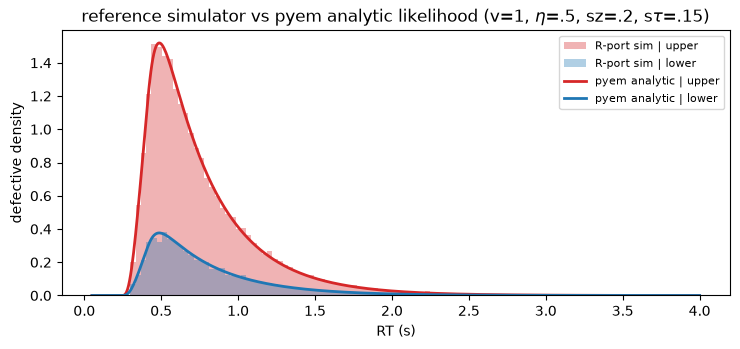

check 2 | dt=0.0050: P(upper)=0.8029  median RT upper=0.6843s


check 2 | dt=0.0020: P(upper)=0.7988  median RT upper=0.6711s


check 2 | dt=0.0001: P(upper)=0.7937  median RT upper=0.6557s
Cross-validation passed: pyem's shared likelihood matches the reference simulator.


In [7]:
def r_simulate_ddm(n_trials=2000, a=1.5, z=0.5, v=1.0, tau=0.3,
                   eta=0.0, sz=0.0, stau=0.0, dt=0.002,
                   max_decision_time=5.0, rng=None):
    """Verbatim Python port of simulate_ddm() from references/index.qmd."""
    rng = rng or np.random.default_rng()
    drift = rng.normal(v, eta, n_trials) if eta > 0 else np.full(n_trials, v)
    z_prop = rng.uniform(z - sz/2, z + sz/2, n_trials) if sz > 0 else np.full(n_trials, z)
    z_prop = np.clip(z_prop, 0.02, 0.98)
    ndt = rng.uniform(tau - stau/2, tau + stau/2, n_trials) if stau > 0 else np.full(n_trials, tau)
    ndt = np.maximum(ndt, 0.0)
    evidence = z_prop * a
    status = np.zeros(n_trials, dtype=int)     # -1 lower, 0 active, +1 upper
    decision_time = np.full(n_trials, np.nan)
    n_steps = int(np.ceil(max_decision_time / dt)); sq = np.sqrt(dt)
    for step in range(1, n_steps + 1):
        active = np.flatnonzero(status == 0)
        if active.size == 0:
            break
        evidence[active] += drift[active] * dt + sq * rng.standard_normal(active.size)
        up = active[evidence[active] >= a]; dn = active[evidence[active] <= 0.0]
        status[up] = 1;  decision_time[up] = step * dt
        status[dn] = -1; decision_time[dn] = step * dt
    return {"status": status, "rt": decision_time + ndt}


# high-vs-low with a FIXED gap == single-condition DDM with drift v = v_coef * gap
Q = (0.1, 0.3, 0.5, 0.7, 0.9)
pars = dict(v=1.0, a=1.5, z=0.5, tau=0.3, eta=0.5, sz=0.2, stau=0.15)  # v = v_coef*gap
s = r_simulate_ddm(n_trials=40000, dt=1e-4, max_decision_time=8.0,
                   rng=np.random.default_rng(3), **pars)
t = np.linspace(0.05, 4.0, 600)
dens_up = np.exp(_marginal_logpdf(t, np.full_like(t, -pars["v"]), pars["a"],
                                  np.full_like(t, 1 - pars["z"]), pars["tau"],
                                  pars["eta"], pars["stau"], pars["sz"]))
dens_lo = np.exp(_marginal_logpdf(t, np.full_like(t, pars["v"]), pars["a"],
                                  np.full_like(t, pars["z"]), pars["tau"],
                                  pars["eta"], pars["stau"], pars["sz"]))
dt_grid = t[1] - t[0]
p_up_analytic = dens_up.sum() * dt_grid
p_up_sim = np.mean(s["status"] == 1)
cdf_up = np.cumsum(dens_up) * dt_grid / p_up_analytic
q_analytic = np.interp(Q, cdf_up, t)
q_sim = np.quantile(s["rt"][s["status"] == 1], Q)
print(f"check 1 | P(upper): analytic={p_up_analytic:.4f} R-port={p_up_sim:.4f} | "
      f"max |RT-quantile diff| = {np.max(np.abs(q_analytic - q_sim)):.4f} s")
assert abs(p_up_analytic - p_up_sim) < 0.01
assert np.max(np.abs(q_analytic - q_sim)) < 0.035

fig, ax = plt.subplots(figsize=(7.5, 3.6))
bins_cv = np.linspace(0.3, 3.0, 80)
for stt, col, lab in ((1, "tab:red", "upper"), (-1, "tab:blue", "lower")):
    rts = s["rt"][s["status"] == stt]
    w = np.full(rts.size, 1.0 / (40000 * (bins_cv[1] - bins_cv[0])))
    ax.hist(rts, bins=bins_cv, weights=w, histtype="stepfilled", alpha=0.35,
            color=col, label=f"R-port sim | {lab}")
ax.plot(t, dens_up, color="tab:red", lw=2, label="pyem analytic | upper")
ax.plot(t, dens_lo, color="tab:blue", lw=2, label="pyem analytic | lower")
ax.set_xlabel("RT (s)"); ax.set_ylabel("defective density")
ax.set_title(r"reference simulator vs pyem analytic likelihood (v=1, $\eta$=.5, sz=.2, s$\tau$=.15)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

for dtv in (0.005, 0.002, 1e-4):
    s3 = r_simulate_ddm(n_trials=30000, dt=dtv, max_decision_time=8.0,
                        rng=np.random.default_rng(4), **pars)
    up = s3["status"] == 1
    print(f"check 2 | dt={dtv:6.4f}: P(upper)={up.mean():.4f}  median RT upper={np.nanmedian(s3['rt'][up]):.4f}s")
print("Cross-validation passed: pyem's shared likelihood matches the reference simulator.")


### Trajectory visualization (high-vs-low task, pyem only)

Finally we reproduce the reference visualiser's signature figure **entirely with
pyem's own simulator**: a handful of evidence trajectories (from `ddm7_sim_paths`, a
visualization helper that follows `ddm7_sim`'s task generation and per-trial draws
exactly) between the two boundaries, with the correct (HIGH/upper) and error
(LOW/lower) RT distributions from a large `ddm7_sim` run drawn as ribbons attached to
their boundaries (areas weighted by the fraction of trials reaching each boundary), the
non-decision period shaded, and the mean start point marked.


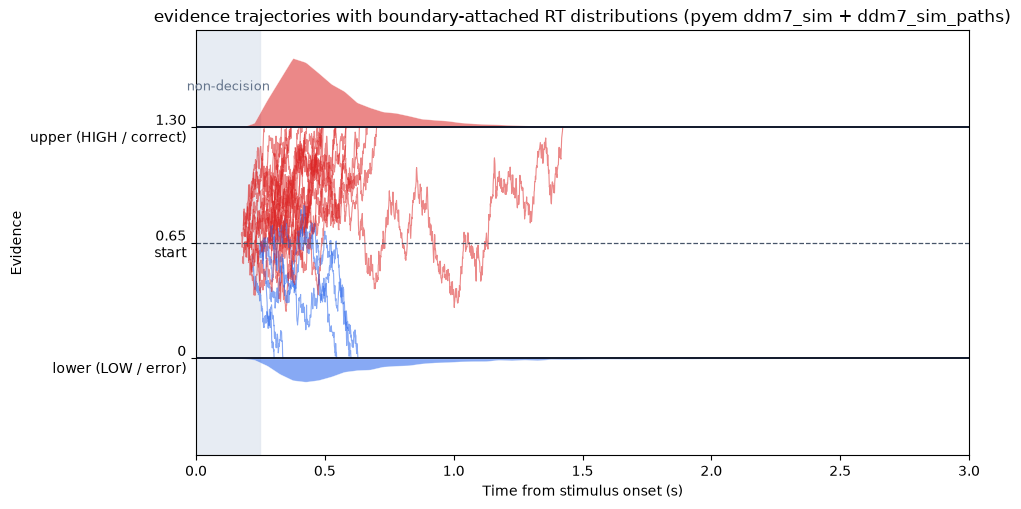

P(correct/HIGH)=0.709, P(error/LOW)=0.291, paths crossed: 25/25


In [8]:
pars_vis = dict(v_coef=1.5, a=1.3, t0=0.25, z=0.5, sv=1.5, st=0.15, sz=0.2)
vec_vis = np.array([[pars_vis[k] for k in ("v_coef", "a", "t0", "z", "sv", "st", "sz")]])
a_vis = pars_vis["a"]

dist_vis = ddm7_sim(vec_vis, ntrials=20000, rng=np.random.default_rng(11))    # ribbons (dt=1e-4)
paths = ddm7_sim_paths(vec_vis[0], ntrials=25, dt=1e-3, max_time=4.0,
                       rng=np.random.default_rng(12))                         # trajectories

rt_vis, ch_vis = dist_vis["rt"][0], dist_vis["choice"][0]
path_colors = {1: "#dc2626", 0: "#2563eb"}     # upper=HIGH red, lower=LOW blue

fig, ax = plt.subplots(figsize=(10, 5.2))
t_max = 3.0
ax.axvspan(0, pars_vis["t0"], color="#e2e8f0", alpha=0.8, zorder=0)
ax.text(pars_vis["t0"] / 2, a_vis * 1.16, "non-decision", ha="center", fontsize=9, color="#64748b")

grid = np.linspace(0, t_max, 400)
ribbon = {}
for key, cval in (("upper", 1), ("lower", 0)):
    rts = rt_vis[ch_vis == cval]
    hist, edges = np.histogram(rts, bins=60, range=(0, t_max), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ribbon[key] = np.interp(grid, centers, hist) * (rts.size / rt_vis.size)
height_scale = 0.30 * a_vis / max(ribbon["upper"].max(), ribbon["lower"].max())
ax.fill_between(grid, a_vis, a_vis + ribbon["upper"] * height_scale,
                color="#dc2626", alpha=0.55, lw=0.4, edgecolor="white")
ax.fill_between(grid, -ribbon["lower"] * height_scale, 0.0,
                color="#2563eb", alpha=0.55, lw=0.4, edgecolor="white")

for t_path, x_path, ch, cr in zip(paths["t"], paths["x"], paths["choice"], paths["crossed"]):
    ax.plot(t_path, x_path, color=path_colors[int(ch)] if cr else "#64748b", alpha=0.55, lw=0.8)

ax.axhline(0, color="#0f172a", lw=1.4)
ax.axhline(a_vis, color="#0f172a", lw=1.4)
ax.axhline(pars_vis["z"] * a_vis, color="#475569", lw=0.9, ls="--")
ax.set_yticks([0, pars_vis["z"] * a_vis, a_vis])
ax.set_yticklabels(["0\nlower (LOW / error)", f"{pars_vis['z'] * a_vis:.2f}\nstart",
                    f"{a_vis:.2f}\nupper (HIGH / correct)"])
ax.set_xlim(0, t_max); ax.set_ylim(-0.42 * a_vis, 1.42 * a_vis)
ax.set_xlabel("Time from stimulus onset (s)"); ax.set_ylabel("Evidence")
ax.set_title("evidence trajectories with boundary-attached RT distributions (pyem ddm7_sim + ddm7_sim_paths)")
plt.tight_layout(); plt.show()

print(f"P(correct/HIGH)={np.mean(ch_vis == 1):.3f}, P(error/LOW)={np.mean(ch_vis == 0):.3f}, "
      f"paths crossed: {int(paths['crossed'].sum())}/25")


### References

- Navarro, D. J., & Fuss, I. G. (2009). Fast and accurate calculations for
  first-passage times in Wiener diffusion models. *Journal of Mathematical
  Psychology*, 53(4), 222-230.
- Ratcliff, R., & Rouder, J. N. (1998). Modeling response times for two-choice
  decisions. *Psychological Science*, 9(5), 347-356.
- Ratcliff, R., & Tuerlinckx, F. (2002). Estimating parameters of the diffusion
  model. *Psychonomic Bulletin & Review*, 9(3), 438-481.
- Ratcliff, R., & McKoon, G. (2008). The diffusion decision model: Theory and data
  for two-choice decision tasks. *Neural Computation*, 20(4), 873-922.
- Henrich, F., Hartmann, R., Pratz, V., Voss, A., & Klauer, K. C. (2024). The
  seven-parameter diffusion model: An implementation in Stan for Bayesian analyses.
  *Behavior Research Methods*, 56, 3102-3116.
- Hartmann, R., & Klauer, K. C. (2021). Partial derivatives for the first-passage time
  distribution in Wiener diffusion models. *Journal of Mathematical Psychology*, 103,
  102550.

The cross-validation reference implementation (R/Shiny visualiser) lives at
`references/index.qmd`. All four models (`ddm4`, `ddm7`, `ddm4_lotto`, `ddm7_lotto`)
are available in `pyem.models.ddm`.
